# Exploring RiPPs with Glycosyltransferase domains and Toxin-Antitoxin

systems using the MGnify BGCs Portal

Santiago Sanchez  
2024-03-10

## Introduction

In this notebook, we will explore how to use the **MGnify Biosynthetic
Gene Clusters (BGCs) portal** and its API to discover **Ribosomally
Synthesised and Post-translationally Modified Peptides (RiPPs)** that
contain glycosyltransferase domains and are associated with
toxin-antitoxin systems.

**RiPPs** are a diverse class of natural products that begin as simple
peptides synthesised by the ribosome. These peptides undergo various
post-translational modifications, resulting in complex structures with
unique biological activities, including antimicrobial, antiviral, and
enzyme-inhibiting properties.

Adding sugar moieties through **glycosyltransferases** can result in
enhanced solubility, stability, and bioactivity of RiPPs, making them
more suitable for therapeutic applications. Additionally, some RiPPs are
associated with **toxin-antitoxin (TA) systems**, where the peptide acts
as a potent toxin neutralised by an antitoxin in the producing organism.

These features make RiPPs with both glycosyl modifications and TA
systems promising in biotechnology for developing new antibiotics,
cancer therapies, biopesticides, and more.

<figure>
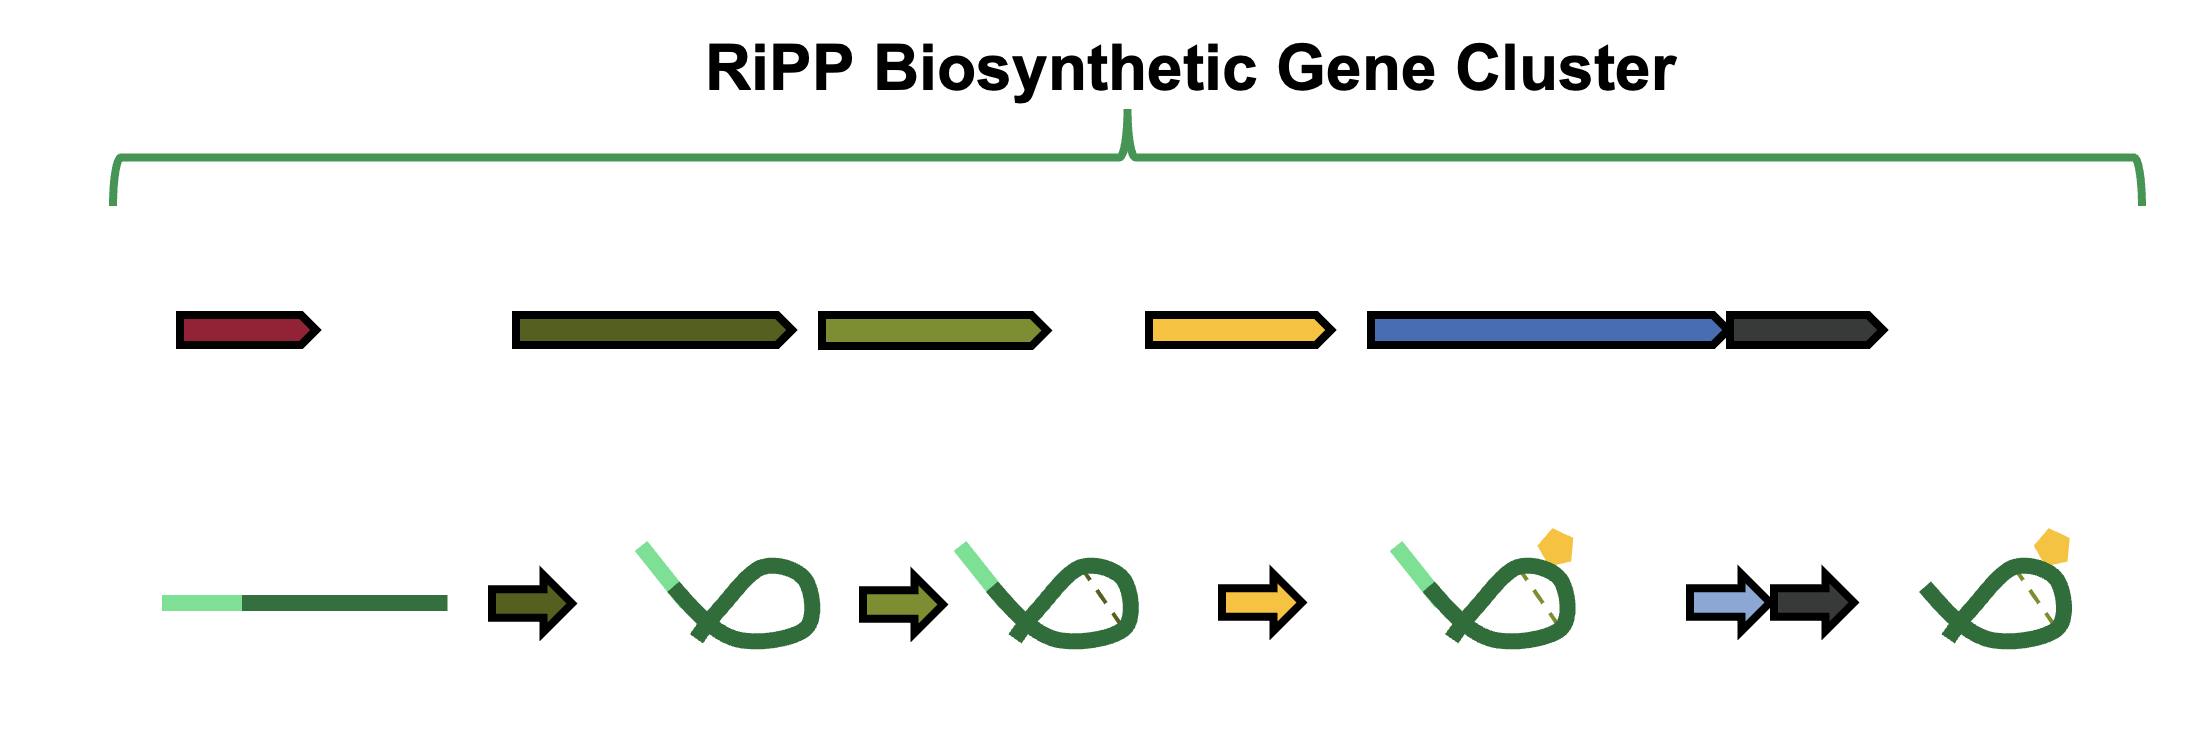
<figcaption aria-hidden="true">Image</figcaption>
</figure>

### Objectives:

-   **Use the MGnify BGCs API** to find RiPPs that:
    -   Contain glycosyltransferase domains.
-   **Download and analyse** the genomic regions of these BGCs.
    -   Find RiPPs associated with antitoxin systems.
-   **Visualise genomic context** to gain further insights into these
    BGCs.
    -   Explore connected resources for further considerations and
        downstream analyses.

## Step 1: Import necessary libraries

First, we install and import the required libraries.

In [ ]:
!pip install tqdm biopython

In [ ]:
import requests
from tqdm import tqdm
import os
from Bio import SeqIO


## Step 2: Identify glycosyltransferase Pfam domains

We need to obtain Pfam accession numbers for glycosyltransferase
domains. Pfam is a database of protein families represented by multiple
sequence alignments and hidden Markov models (HMMs). Pfam is widley used
for functional annotation of genes.

-   Visit the [InterPro entry for
    glycosyltransferases](https://www.ebi.ac.uk/interpro/entry/pfam/?search=glycosyltransferase#table).
-   Download the table of Pfam entries related to glycosyltransferases.
-   Extract the Pfam accession numbers.

For this example, we’ll use a predefined list of glycosyltransferase
Pfam accessions.

In [ ]:
# List of Pfam accessions for glycosyltransferases
glycosyltransferase_pfams = [
    'PF00777', 'PF00852', 'PF00982', 'PF01075', 'PF01697', 'PF01755', 'PF03033', 'PF03155',
    'PF03360', 'PF03385', 'PF03414', 'PF04101', 'PF04488', 'PF04572', 'PF04577', 'PF04724',
    'PF04765', 'PF06165', 'PF07922', 'PF08759', 'PF09594', 'PF10111', 'PF11397', 'PF12919',
    'PF13439', 'PF13641', 'PF13712', 'PF14307', 'PF15024', 'PF16849', 'PF18674', 'PF20156',
    'PF20157', 'PF20471', 'PF20691', 'PF20706', 'PF21129', 'PF21912'
    ]
print(f"Number of glycosyltransferase Pfam domains: {len(glycosyltransferase_pfams)}")


## Step 3: Construct API queries to search for RiPPs with glycosyltransferase domains

We will use the MGnify BGCs API to search for BGCs that:

-   Are classified as **RiPPs**.
-   Contain one or more **glycosyltransferase Pfam domains**.
-   Detected by at least one tool (antiSMASH, GECCO, SanntiS).

We define a function to build the API URL with the required parameters.

In [ ]:

# Base URL for the advanced search API
base_api_url = "http://ebi.ac.uk/finn-srv/mgnify-bgcs/api/v1/advanced_search/"

# Parameters for the API query
bgc_class = 'RiPP'
detectors = ['antiSMASH', 'GECCO', 'SanntiS']
pfam_strategy = 'union'
aggregate_strategy = 'single'
page_limit = 100  # Number of results per page

# Function to build the API URL for a given Pfam accession
def build_api_url(pfam_accession, offset=0):
    params = {
        'bgc_class_name': bgc_class,
        'completeness': [0, 1, 2],
        'protein_pfam': pfam_accession,
        'pfam_strategy': pfam_strategy,
        'detectors': detectors,
        'aggregate_strategy': aggregate_strategy,
        'limit': page_limit,
        'offset': offset
    }
    # Build the query string
    query_string = '&'.join([f"{key}={value}" if not isinstance(value, list) else '&'.join([f"{key}={v}" for v in value]) for key, value in params.items()])
    return f"{base_api_url}?{query_string}"


## Step 4: Fetch BGCs matching the criteria

We loop through each glycosyltransferase Pfam accession and retrieve all
matching BGCs.

In [ ]:

# List to store all BGC entries
all_bgcs = []

# Loop through each Pfam accession
for pfam_acc in tqdm(glycosyltransferase_pfams, desc="Processing Pfam domains"):
    offset = 0
    total_results = 1  # Initialise with a value greater than 0
    while offset < total_results:
        # Build the API URL
        api_url = build_api_url(pfam_acc, offset=offset)
        # Make the API request
        response = requests.get(api_url)
        if response.status_code == 200:
            data = response.json()
            total_results = data['count']
            all_bgcs.extend(data['items'])
            offset += page_limit
        else:
            print(f"Failed to fetch data for Pfam {pfam_acc}. Status code: {response.status_code}")
            break  # Exit the loop for this Pfam accession
print(f"BGC prediction found with at least one glycosyltransferase domain: {len(all_bgcs)}")

## Step 5: Download GenBank files of the BGCs using the portal’s API

We download the GenBank files of the BGC regions for further analysis.

In [ ]:
# Directory to save the GBK files
output_dir = "bgc_gbk_files"
os.makedirs(output_dir, exist_ok=True)

# URL template for fetching the GBK files
gbk_url_template = "http://ebi.ac.uk/finn-srv/mgnify-bgcs/api/v1/contig_region/?mgyc={}&start_position={}&end_position={}&output_type=gbk"

# Loop through all BGC entries and download the GBK files
for bgc in tqdm(all_bgcs, desc="Downloading GBK files"):
    mgyc = bgc['contig_mgyc']
    start = bgc['start_position']
    end = bgc['end_position']

    # Construct the GBK URL
    gbk_url = gbk_url_template.format(mgyc, start, end)

    # File path to save the GBK file
    filename = f"{mgyc}_{start}_{end}.gbk"
    filepath = os.path.join(output_dir, filename)

    # Check if the file already exists
    if not os.path.isfile(filepath):
        # Send request to fetch GBK file
        response = requests.get(gbk_url)
        if response.status_code == 200:
            with open(filepath, 'wb') as file:
                file.write(response.content)
        else:
            print(f"Failed to fetch GBK file for {mgyc}. Status code: {response.status_code}")


## Step 6: Identify BGCs associated with Toxin-Antitoxin systems

We parse the downloaded GBK files to search for annotations containing
‘antitoxin’.

In [ ]:

# List to store BGCs associated with antitoxin systems
antitoxin_regions = []

# Loop through the GBK files and parse annotations
for bgc in tqdm(all_bgcs, desc="Parsing GBK files for antitoxin annotations"):
    mgyc = bgc['contig_mgyc']
    start = bgc['start_position']
    end = bgc['end_position']

    # File path to the GBK file
    filename = f"{mgyc}_{start}_{end}.gbk"
    filepath = os.path.join(output_dir, filename)

    try:

        # Parse the GBK file
        with open(filepath, 'r') as gbk_file:
            record = SeqIO.read(gbk_file, "genbank")

        # Flag to indicate if antitoxin annotation is found
        FLAG =False
        glycos = []
        antitoxin_pfam = []

        # Iterate through features
        for feature in record.features:
            if feature.type == "ANNOT":
                # Check if the feature has a 'description' qualifier
                if 'description' in feature.qualifiers:
                    description = feature.qualifiers['description'][0]  # Get the description text
                    ID = feature.qualifiers['ID'][0]  # Get the description text

                    # Check if 'antitoxin' is present in the description (case-insensitive)
                    if 'antitoxin' in description.lower():
                        # If found, save the mgyc, start, and end values
                        FLAG=True
                        antitoxin_pfam.append(ID)
                    if ID in glycosyltransferase_pfams:
                         glycos.append(ID)
        if FLAG:
            antitoxin_regions.append((mgyc, start, end,antitoxin_pfam,glycos))
            FLAG =False

    except Exception as e:
        print(f"Error parsing GBK file {filename}: {e}")


## Step 7: Visualise the found RiPPs using the BGC Portal

Now that we have identified BGCs that are RiPPs, contain
glycosyltransferase domains, and are associated with antitoxin systems,
we can explore these BGCs further using the **MGnify BGCs portal**.

For each BGC, we will:

-   Construct the URL to the BGC’s page on the MGnify BGCs portal.
-   Explore the genomic context and annotations.
-   Examine the specific CDS related to the toxin-antitoxin systems.
-   View the representative protein pages to see protein structures and
    distribution across biomes.
-   Access the sample information in MGnify to learn about the sample’s
    origin, geographic location, and ABS (Access and Benefit Sharing)
    compliance considerations.

In [ ]:

# Iterate over the antitoxin_regions
for region in antitoxin_regions:
    mgyc = region[0]
    start = region[1]
    end = region[2]
    antitoxin_pfams = region[3]
    glycosyltransferase_pfams_in_bgc = region[4]

    # Construct the URL to the BGC portal page for this BGC
    bgc_url = f"http://ebi.ac.uk/finn-srv/mgnify-bgcs/bgc/{mgyc}/{start}/{end}/"

    print(f"BGC URL: {bgc_url}")
    print(f"Antitoxin Pfam Domains: {antitoxin_pfams}")
    print(f"Glycosyltransferase Pfam Domains in BGC: {glycosyltransferase_pfams_in_bgc}")
    print("Visit this URL to explore the BGC in detail.")
    print("---")



## Step 8: Summary and conclusions

In this notebook, we:

-   **Used the MGnify BGCs API** to search for RiPP BGCs containing
    glycosyltransferase domains.
-   **Downloaded and parsed** GenBank files to identify BGCs associated
    with antitoxin systems.
-   **Visualised and analysed** results using the MGnify BGCs portal to
    have a better understanding of result.
-   **Explored connected resources**, improved contextualisation of the
    BGCs by exploring sample metadata and links from other resources for
    further analysis.

This workflow demonstrates how to integrate **MGnify BGCs portal** to
other bioinformatics tools and databases to accelerate natural product
discovery.

### Next Steps:

-   **Analyse protein sequences** using tools like BLAST or
    InterProScan.
-   **Predict biosynthetic pathways** and potential structures of the
    natural products.
-   **Assess legal and ethical considerations**, including ABS
    obligations.

------------------------------------------------------------------------

## References

-   **MGnify BGCs Portal**: <http://ebi.ac.uk/finn-srv/mgnify-bgcs/>
-   **MGnify API Documentation**:
    <http://ebi.ac.uk/finn-srv/mgnify-bgcs/api/v1/docs/>
-   **MGnify**:
    [https://www.ebi.ac.uk/metagenomics/](https://www.ebi.ac.uk/metagenomics)
-   **MGnify Proteins**:
    [https://www.ebi.ac.uk/metagenomics/proteins/](https://www.ebi.ac.uk/metagenomics/proteins)
-   **Interpro**: <https://www.ebi.ac.uk/interpro/>

------------------------------------------------------------------------

## Conclusion

By following this notebook, you’ve learned how to leverage the MGnify
BGCs portal and API for targeted natural product discovery. This
approach can be adapted to search for other classes of BGCs or
functional domains, facilitating the exploration of the vast diversity
of microbial natural products.